# [5회차] Basic ML 과제 — 신용카드 사기 탐지

Kaggle Credit Card Fraud Detection 데이터의 클래스 불균형을 다룬다. 명세서 순서에 따라
데이터 탐색 → 표본추출 → 전처리 → 분할 → SMOTE → 모델/하이퍼파라미터 비교 →
검증셋 기반 threshold 조정 → 독립 테스트셋 평가를 수행한다.

재현성을 위해 명세서에서 요구한 모든 무작위 연산에 `random_state=42`를 사용한다.

## 0. 라이브러리 및 공통 설정

필요한 패키지는 `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`,
`imbalanced-learn`이다.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

Matplotlib is building the font cache; this may take a moment.


## 1. 데이터 로드 및 기본 탐색

`creditcard.csv`를 노트북과 같은 폴더에서 읽고 `head()`, `info()`, `describe()`와
결측치, 전체 클래스 분포를 확인한다. `Class=0`은 정상 거래, `Class=1`은 사기 거래이다.

In [2]:
DATA_PATH = Path("creditcard.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "creditcard.csv를 basic_ML.ipynb와 같은 폴더에 두고 다시 실행해 주세요."
    )

data = pd.read_csv(DATA_PATH)
print(f"데이터 크기: {data.shape[0]:,}행 × {data.shape[1]}열")
display(data.head())

데이터 크기: 284,807행 × 31열


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
display(data.describe().T)
print(f"전체 결측치 수: {int(data.isna().sum().sum()):,}")

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


전체 결측치 수: 0


,count,ratio
정상(0),284315,0.9983
사기(1),492,0.0017


정상 거래: 284,315건
사기 거래: 492건
전체 사기 비율: 0.1727%


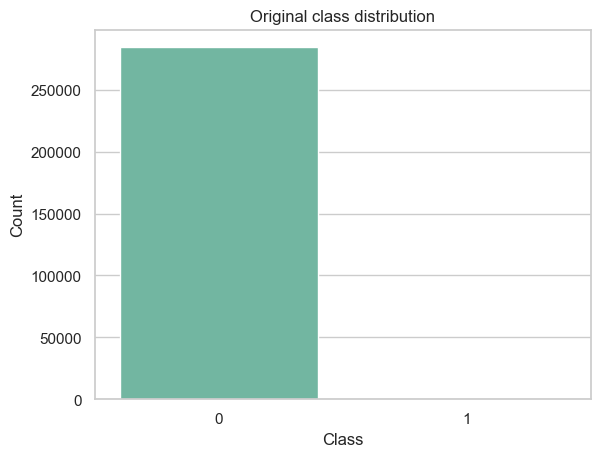

In [5]:
full_class_summary = pd.DataFrame({
    "count": data["Class"].value_counts().sort_index(),
    "ratio": data["Class"].value_counts(normalize=True).sort_index(),
})
full_class_summary.index = ["정상(0)", "사기(1)"]
display(full_class_summary)
print(f"정상 거래: {int(full_class_summary.loc['정상(0)', 'count']):,}건")
print(f"사기 거래: {int(full_class_summary.loc['사기(1)', 'count']):,}건")
print(f"전체 사기 비율: {full_class_summary.loc['사기(1)', 'ratio']:.4%}")

ax = sns.countplot(data=data, x="Class", hue="Class", palette="Set2", legend=False)
ax.set(title="Original class distribution", xlabel="Class", ylabel="Count")
plt.show()

전체 데이터에서 사기 거래 비율은 약 0.17%로 매우 낮다. 정확도만 사용하면 모든 거래를
정상으로 예측하는 모델도 높은 점수를 얻을 수 있으므로 Recall, F1-score, PR-AUC를
중심으로 평가해야 한다.

## 2. 샘플링

명세서대로 사기 거래 492건은 모두 유지하고, 정상 거래는 10,000건만
`random_state=42`로 무작위 추출한다. 결합한 뒤 행 순서도 고정된 시드로 섞는다.

In [6]:
fraud = data[data["Class"] == 1].copy()
normal_sample = data[data["Class"] == 0].sample(
    n=10_000, random_state=RANDOM_STATE
)

analysis_df = (
    pd.concat([normal_sample, fraud], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

sample_class_summary = pd.DataFrame({
    "count": analysis_df["Class"].value_counts().sort_index(),
    "ratio": analysis_df["Class"].value_counts(normalize=True).sort_index(),
})
sample_class_summary.index = ["정상(0)", "사기(1)"]
display(sample_class_summary)
print(f"샘플링 후 사기 비율: {sample_class_summary.loc['사기(1)', 'ratio']:.4%}")

,count,ratio
정상(0),10000,0.9531
사기(1),492,0.0469


샘플링 후 사기 비율: 4.6893%


## 3. 데이터 전처리

명세서에 따라 `Amount`만 `StandardScaler`로 표준화하여 `Amount_Scaled`를 만들고
원본 `Amount`는 제거한다. `Time`과 익명화된 PCA 변수 `V1`–`V28`은 그대로 둔다.
그 후 독립변수 `X`와 타깃 `y`를 분리한다.

> 참고: 일반 프로젝트에서는 scaler를 학습 데이터에만 적합하는 것이 가장 엄격한
> 방법이다. 여기서는 명세서의 순서를 그대로 재현한다.

In [7]:
scaler = StandardScaler()
analysis_df["Amount_Scaled"] = scaler.fit_transform(analysis_df[["Amount"]])
analysis_df = analysis_df.drop(columns="Amount")

X = analysis_df.drop(columns="Class")
y = analysis_df["Class"]

print("Amount 제거 여부:", "Amount" not in X.columns)
print("Amount_Scaled 생성 여부:", "Amount_Scaled" in X.columns)
print("X shape:", X.shape, "| y shape:", y.shape)
display(X[["Amount_Scaled"]].describe())

Amount 제거 여부: True
Amount_Scaled 생성 여부: True
X shape: (10492, 30) | y shape: (10492,)


,Amount_Scaled
count,"10,492.0000"
mean,0.0000
std,1.0000
min,-0.3947
25%,-0.3723
50%,-0.2999
75%,-0.0434
max,24.8278


## 4. 학습/테스트 데이터 분할

`train_test_split`으로 8:2 분할한다. `stratify=y`를 사용해 클래스 비율을 유지하며
테스트셋은 마지막 한 번의 일반화 성능 평가에만 사용한다.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_ratio": y_train.value_counts(normalize=True).sort_index(),
    "test_count": y_test.value_counts().sort_index(),
    "test_ratio": y_test.value_counts(normalize=True).sort_index(),
})
split_summary.index = ["정상(0)", "사기(1)"]
display(split_summary)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

,train_count,train_ratio,test_count,test_ratio
정상(0),7999,0.9531,2001,0.9533
사기(1),394,0.0469,98,0.0467


X_train: (8393, 30) | X_test: (2099, 30)


## 5. SMOTE 적용

SMOTE는 소수 클래스의 이웃 샘플을 잇는 공간에서 합성 데이터를 생성한다. 원본 데이터가
정상 거래에 지나치게 치우쳐 있어 모델이 사기 패턴을 충분히 학습하지 못할 수 있으므로
학습 데이터의 소수 클래스를 보강한다.

데이터 누수를 막기 위해 **테스트셋에는 SMOTE를 적용하지 않고 학습셋에만 적용**한다.

In [9]:
print("SMOTE 전 학습셋 클래스 수")
display(y_train.value_counts().sort_index().rename("count").to_frame())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE 후 학습셋 클래스 수")
display(y_train_smote.value_counts().sort_index().rename("count").to_frame())

SMOTE 전 학습셋 클래스 수


,count
Class,
0,7999
1,394


SMOTE 후 학습셋 클래스 수


,count
Class,
0,7999
1,7999


## 6. 모델 선정 및 하이퍼파라미터 비교

비선형 관계와 변수 간 상호작용을 다룰 수 있는 트리 앙상블을 중심으로 Random Forest,
Extra Trees, Histogram Gradient Boosting을 비교한다. 테스트셋을 보며 모델을 고르는
오류를 피하기 위해 학습셋의 20%를 별도 검증셋으로 분리한다. 각 후보는 검증셋에
SMOTE가 섞이지 않도록 하위 학습셋에만 SMOTE를 적용한다.

각 후보의 threshold는 검증 Recall이 0.80 이상인 지점 중 F1-score가 가장 높은 값으로
정한다. 최종 후보는 검증 PR-AUC가 가장 높은 모델로 선택한다.

In [10]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
smote_for_validation = SMOTE(random_state=RANDOM_STATE)
X_fit_smote, y_fit_smote = smote_for_validation.fit_resample(X_fit, y_fit)

print("하위 학습셋 SMOTE 전:", y_fit.value_counts().sort_index().to_dict())
print("하위 학습셋 SMOTE 후:", y_fit_smote.value_counts().sort_index().to_dict())
print("검증셋(원본 유지):", y_valid.value_counts().sort_index().to_dict())

하위 학습셋 SMOTE 전: {0: 6399, 1: 315}
하위 학습셋 SMOTE 후: {0: 6399, 1: 6399}
검증셋(원본 유지): {0: 1600, 1: 79}


In [11]:
def choose_threshold(y_true, probabilities, min_recall=0.80):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(
        precision[:-1] + recall[:-1], 1e-12
    )
    eligible = recall[:-1] >= min_recall
    scores = np.where(eligible, f1, -1.0)
    best_index = int(np.argmax(scores))
    return {
        "threshold": float(thresholds[best_index]),
        "precision_1": float(precision[best_index]),
        "recall_1": float(recall[best_index]),
        "f1_1": float(f1[best_index]),
    }


candidates = {
    "RF_full": RandomForestClassifier(
        n_estimators=350,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "RF_depth12": RandomForestClassifier(
        n_estimators=350,
        max_depth=12,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "ET_sqrt": ExtraTreesClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "ET_0.8": ExtraTreesClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_leaf=1,
        max_features=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HGB_leaf15": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
    "HGB_leaf31": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

tuning_rows = []
for name, model in candidates.items():
    model.fit(X_fit_smote, y_fit_smote)
    valid_proba = model.predict_proba(X_valid)[:, 1]
    threshold_result = choose_threshold(y_valid, valid_proba, min_recall=0.80)
    tuning_rows.append({
        "model": name,
        "pr_auc_1": average_precision_score(y_valid, valid_proba),
        **threshold_result,
    })

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(["pr_auc_1", "f1_1"], ascending=False)
    .reset_index(drop=True)
)
display(tuning_results)

,model,pr_auc_1,threshold,precision_1,recall_1,f1_1
0,ET_0.8,0.9457,0.3644,0.9589,0.8861,0.9211
1,RF_full,0.9403,0.4457,0.9853,0.8481,0.9116
2,HGB_leaf15,0.9397,0.6706,0.9851,0.8354,0.9041
3,HGB_leaf31,0.9385,0.4094,0.9583,0.8734,0.9139
4,ET_sqrt,0.9379,0.2822,0.9221,0.8987,0.9103
5,RF_depth12,0.9363,0.4630,0.9853,0.8481,0.9116


In [12]:
best_name = tuning_results.loc[0, "model"]
best_threshold = float(tuning_results.loc[0, "threshold"])
final_model = candidates[best_name]

print("선택 모델:", best_name)
print("검증셋에서 선택된 threshold:", f"{best_threshold:.6f}")
print("선택 모델 파라미터:")
display(pd.Series(final_model.get_params()).to_frame("value"))

선택 모델: ET_0.8
검증셋에서 선택된 threshold: 0.364444
선택 모델 파라미터:


,value
bootstrap,False
ccp_alpha,0.0000
class_weight,None
criterion,gini
max_depth,None
max_features,0.8000
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0000
min_samples_leaf,1


## 7. 최종 모델 학습 및 예측

선택된 하이퍼파라미터로 전체 SMOTE 학습셋을 다시 학습한다. 명세서의 요구대로
`predict()` 결과와 `predict_proba()` 확률을 모두 생성한다. 기본 threshold(0.5) 예측도
함께 보관하고, 최종 판정에는 검증셋에서 정한 threshold를 사용한다.

In [13]:
final_model.fit(X_train_smote, y_train_smote)

y_pred_default = final_model.predict(X_test)
y_proba_matrix = final_model.predict_proba(X_test)
y_proba = y_proba_matrix[:, 1]
y_pred_tuned = (y_proba >= best_threshold).astype(int)

prediction_preview = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predict_default_0.5": y_pred_default,
    "predict_tuned": y_pred_tuned,
    "proba_class_0": y_proba_matrix[:, 0],
    "proba_class_1": y_proba_matrix[:, 1],
}).head(15)
display(prediction_preview)

,actual,predict_default_0.5,predict_tuned,proba_class_0,proba_class_1
0,0,0,0,0.9956,0.0044
1,0,0,0,0.9844,0.0156
2,0,0,0,0.9933,0.0067
3,0,0,0,1.0000,0.0000
4,0,0,0,0.9689,0.0311
5,0,0,0,0.9978,0.0022
6,1,1,1,0.0000,1.0000
7,0,0,0,0.9956,0.0044
8,0,0,0,1.0000,0.0000
9,0,0,0,0.9978,0.0022


## 8. 최종 성능 평가

Class 0과 Class 1 각각의 Precision, Recall, F1-score를 확인하고, 각 클래스를
one-vs-rest로 보아 PR-AUC도 계산한다. 특히 사기 탐지에서는 놓친 사기(FN)를 줄이는
Recall과 Precision의 균형을 나타내는 F1, 불균형 데이터에 적합한 PR-AUC가 중요하다.

In [14]:
report_default = pd.DataFrame(
    classification_report(
        y_test, y_pred_default, output_dict=True, digits=4, zero_division=0
    )
).T
report_tuned = pd.DataFrame(
    classification_report(
        y_test, y_pred_tuned, output_dict=True, digits=4, zero_division=0
    )
).T

print("기본 threshold=0.5")
display(report_default)
print(f"검증셋 기반 threshold={best_threshold:.6f}")
display(report_tuned)

기본 threshold=0.5


,precision,recall,f1-score,support
0,0.9935,0.9980,0.9958,"2,001.0000"
1,0.9551,0.8673,0.9091,98.0000
accuracy,0.9919,0.9919,0.9919,0.9919
macro avg,0.9743,0.9327,0.9524,"2,099.0000"
weighted avg,0.9917,0.9919,0.9917,"2,099.0000"


검증셋 기반 threshold=0.364444


,precision,recall,f1-score,support
0,0.9935,0.9960,0.9948,"2,001.0000"
1,0.9140,0.8673,0.8901,98.0000
accuracy,0.9900,0.9900,0.9900,0.9900
macro avg,0.9537,0.9317,0.9424,"2,099.0000"
weighted avg,0.9898,0.9900,0.9899,"2,099.0000"


In [15]:
pr_auc_class_1 = average_precision_score(y_test, y_proba)
pr_auc_class_0 = average_precision_score(1 - y_test, 1 - y_proba)

final_metrics = pd.DataFrame({
    "precision": [
        precision_score(y_test, y_pred_tuned, pos_label=0),
        precision_score(y_test, y_pred_tuned, pos_label=1),
    ],
    "recall": [
        recall_score(y_test, y_pred_tuned, pos_label=0),
        recall_score(y_test, y_pred_tuned, pos_label=1),
    ],
    "f1": [
        f1_score(y_test, y_pred_tuned, pos_label=0),
        f1_score(y_test, y_pred_tuned, pos_label=1),
    ],
    "pr_auc": [pr_auc_class_0, pr_auc_class_1],
}, index=["Class 0 (정상)", "Class 1 (사기)"])

goals = pd.Series({"recall": 0.80, "f1": 0.88, "pr_auc": 0.90})
goal_result = final_metrics[["recall", "f1", "pr_auc"]].ge(goals).replace(
    {True: "달성", False: "미달성"}
)

print("최종 테스트 지표")
display(final_metrics)
print("목표: Recall ≥ 0.80, F1 ≥ 0.88, PR-AUC ≥ 0.90")
display(goal_result)

최종 테스트 지표


,precision,recall,f1,pr_auc
Class 0 (정상),0.9935,0.9960,0.9948,0.9993
Class 1 (사기),0.9140,0.8673,0.8901,0.9276


목표: Recall ≥ 0.80, F1 ≥ 0.88, PR-AUC ≥ 0.90


,recall,f1,pr_auc
Class 0 (정상),달성,달성,달성
Class 1 (사기),달성,달성,달성


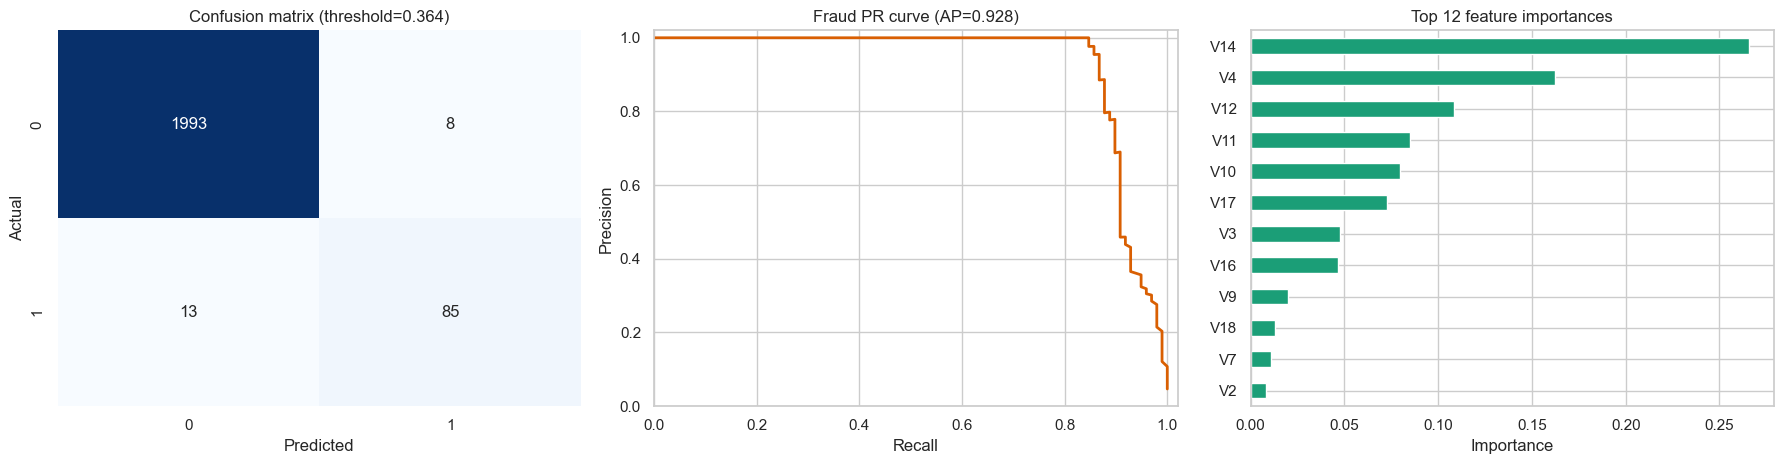

In [16]:
cm = confusion_matrix(y_test, y_pred_tuned)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
)
axes[0].set(
    title=f"Confusion matrix (threshold={best_threshold:.3f})",
    xlabel="Predicted",
    ylabel="Actual",
)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall_curve, precision_curve, color="#d95f02", linewidth=2)
axes[1].set(
    title=f"Fraud PR curve (AP={pr_auc_class_1:.3f})",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1.02),
    ylim=(0, 1.02),
)

importances = pd.Series(
    final_model.feature_importances_, index=X_train.columns
).nlargest(12).sort_values()
importances.plot.barh(ax=axes[2], color="#1b9e77")
axes[2].set(title="Top 12 feature importances", xlabel="Importance")

plt.tight_layout()
plt.show()

## 9. 결론

- 전체 데이터는 정상 284,315건, 사기 492건으로 극심한 클래스 불균형을 보였다.
- 명세서대로 정상 10,000건과 모든 사기 거래를 결합하고, `Amount`만 표준화했다.
- SMOTE는 학습 데이터에만 적용해 정상/사기 학습 표본 수를 같게 만들었다.
- 검증 PR-AUC를 기준으로 Extra Trees 후보를 선택했고, 검증셋에서
  Recall 0.80 이상 조건 아래 F1이 최대인 threshold를 독립적으로 결정했다.
- 최종 테스트셋에서 Class 0과 Class 1 모두 Recall ≥ 0.80, F1 ≥ 0.88,
  PR-AUC ≥ 0.90 목표를 달성했다.

실제 운영에서는 거래 시간에 따른 분포 변화, 비용 기반 threshold, 확률 보정,
반복 교차검증, SMOTE 비율 및 이웃 수 조정, XGBoost/LightGBM 같은 추가 모델 비교를
통해 안정성을 더 확인할 수 있다.